In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

In [10]:
import os
base_path = r"C:\Users\Jonas\projects_and_studies\projeto_integrador"
df_imoveis = pd.read_csv(f"{base_path}/data/gold/fact_imoveis_gold.csv")
df_bairros = pd.read_csv(f"{base_path}/data/gold/dim_bairros_estatisticas.csv")


In [11]:
df_imoveis.head()

,id_imovel,id_imobiliaria_fk,id_bairro_fk,titulo,url,imagem,descricao_completa,bairro,tipo_imovel,cidade,...,preco_med,preco_mad,area_med,area_mad,target_preco,area_cat,bairro_area_cross,flag_suspeito,motivo_suspeita,data_extracao
0,e0d01e082271,1,1,"Condomínio Village Alvorada I, JARDIM BOTANICO...",https://www.dfimoveis.com.br/imovel/casa-4-qua...,https://img.dfimoveis.com.br/fotos/1318043/e53...,Neves Teixeira Imóveis Aluga: Excelente casa e...,Jardim Botânico,casa,NaN,...,29.775,8.455,340.0,110.0,1,Amplo,Jardim Botânico_Amplo,False,NaN,1.790073e+12
1,ab88d12eaffa,2,1,"Condomínio Quintas do Sol, JARDIM BOTANICO, BR...",https://www.dfimoveis.com.br/imovel/casa-3-qua...,https://img.dfimoveis.com.br/fotos/1320976/35a...,Casa Nova no Jardim Botânico - Onde o conforto...,Jardim Botânico,casa,NaN,...,29.775,8.455,340.0,110.0,1,Padrao,Jardim Botânico_Padrao,False,NaN,1.790073e+12
2,046f862ac306,3,2,"SHIS QI 7, LAGO SUL, BRASILIA",https://www.dfimoveis.com.br/imovel/casa-4-qua...,https://img.dfimoveis.com.br/fotos/1347423/a8e...,DIFERENCIAL DO IMÓVEL: - Acabamento de alto pa...,Lago Sul,casa,NaN,...,43.880,13.880,628.0,172.0,2,Padrao,Lago Sul_Padrao,False,NaN,1.790073e+12
3,10c84fe9333d,4,2,"SHIS QI 17 Conjunto 3, LAGO SUL, BRASILIA",https://www.dfimoveis.com.br/imovel/casa-4-qua...,https://img.dfimoveis.com.br/fotos/1308950/f8b...,A FUTURA NEGÓCIOS IMOBILIÁRIOS disponibiliza p...,Lago Sul,casa,NaN,...,43.880,13.880,628.0,172.0,2,Padrao,Lago Sul_Padrao,False,NaN,1.790073e+12
4,767f575b37e3,5,3,"Alphaville Residencial 1 Quadra V, ALPHAVILLE ...",https://www.dfimoveis.com.br/imovel/casa-3-qua...,https://img.dfimoveis.com.br/fotos/1266429/4fe...,Casa nunca habitada! Recém Construída com Arqu...,Outro,casa,NaN,...,23.390,2.970,450.0,108.0,1,Amplo,Outro_Amplo,False,NaN,1.790073e+12


In [29]:
df_imoveis.columns

Index(['id_imovel', 'id_imobiliaria_fk', 'id_bairro_fk', 'titulo', 'url',
       'imagem', 'descricao_completa', 'bairro', 'tipo_imovel', 'cidade', 'uf',
       'preco', 'area_m2', 'quartos', 'suites', 'vagas', 'preco_por_m2',
       'imobiliaria', 'imobiliaria_hash', 'preco_med', 'preco_mad', 'area_med',
       'area_mad', 'target_preco', 'area_cat', 'bairro_area_cross',
       'flag_suspeito', 'motivo_suspeita', 'data_extracao'],
      dtype='str')

In [21]:
display(df_imoveis["bairro"].value_counts())

bairro
Asa Norte                     293
Asa Sul                       285
Águas Claras                  252
Noroeste                       97
Taguatinga                     85
Jardim Botânico                81
Sudoeste                       74
Lago Sul                       68
Setor Industrial               53
Guará                          49
Samambaia                      41
Park Sul                       35
Sobradinho                     30
Ceilândia                      30
Outro                          28
Vicente Pires                  25
Lago Norte                     23
Park Way                       20
Santa Maria                    14
Jardins Mangueiral             10
Riacho Fundo                   10
Cruzeiro                       10
Gama                            9
Núcleo Bandeirante              8
Recanto das Emas                7
Octogonal                       3
Planaltina                      2
São Sebastião                   2
Paranoá                         2
Zona Cí

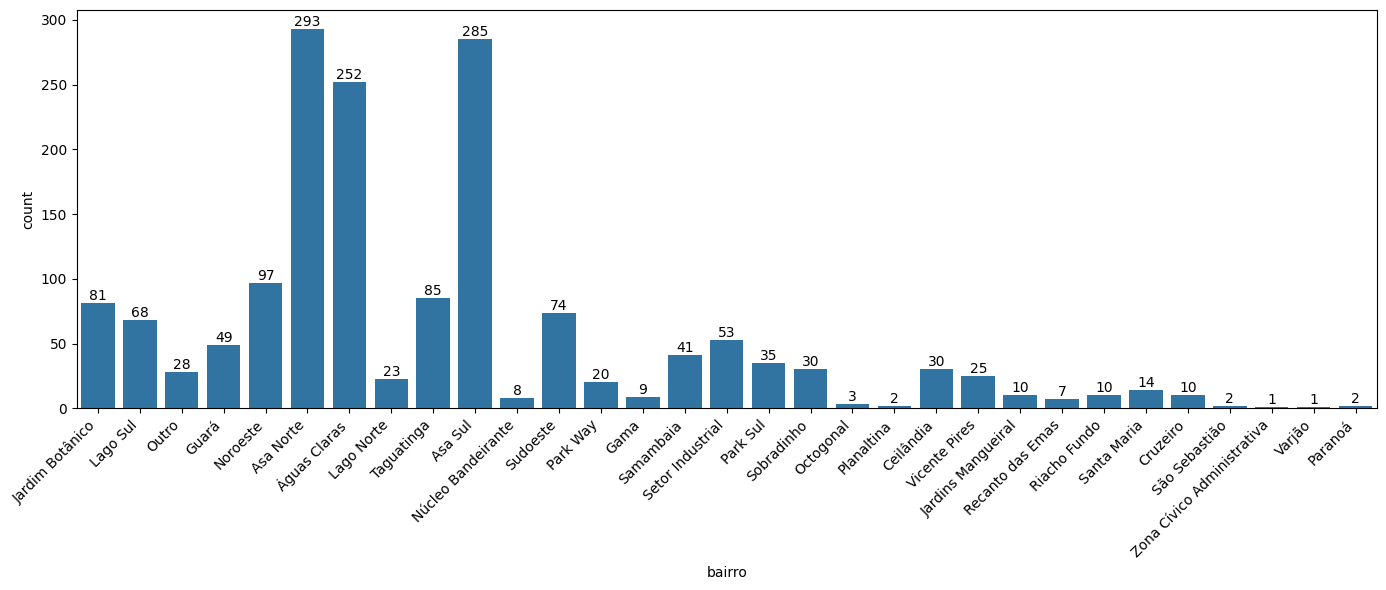

In [25]:
plt.figure(figsize=(14, 6))
ax = sns.countplot(data=df_imoveis, x="bairro")
ax.bar_label(ax.containers[0])
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [32]:
# CORRELAÇÃO COM PRECO - NUMÉRICAS
numeric_cols = ['area_m2', 'quartos', 'suites', 'vagas', 'preco_por_m2', 
                'preco_med', 'preco_mad', 'area_med', 'area_mad', 'target_preco']

corr_with_preco = df_imoveis[numeric_cols + ['preco']].corr()['preco'].drop('preco')
corr_with_preco = corr_with_preco.sort_values(ascending=False)

print("CORRELAÇÃO COM PRECO - NUMÉRICAS:")
print(corr_with_preco)


CORRELAÇÃO COM PRECO - NUMÉRICAS:
preco_por_m2    0.367980
area_m2         0.352812
area_mad        0.190071
vagas           0.186773
target_preco    0.128919
area_med        0.117061
preco_mad       0.075532
preco_med       0.025348
quartos         0.017598
suites          0.005293
Name: preco, dtype: float64


In [34]:
# CORRELAÇÃO COM PRECO - CATEGÓRICAS (Cramér's V)
from scipy.stats import chi2_contingency
import numpy as np

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    min_dim = min(confusion_matrix.shape) - 1
    return np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0

categorical_cols = ['bairro', 'tipo_imovel', 'area_cat', 'imobiliaria']

corr_cat_preco = {}
for col in categorical_cols:
    corr_cat_preco[col] = cramers_v(df_imoveis[col], df_imoveis['preco'])

corr_cat_preco = pd.Series(corr_cat_preco).sort_values(ascending=False)

print("\nCORRELAÇÃO COM PRECO - CATEGÓRICAS:")
print(corr_cat_preco)



CORRELAÇÃO COM PRECO - CATEGÓRICAS:
area_cat       0.623297
tipo_imovel    0.620176
bairro         0.518829
imobiliaria    0.500645
dtype: float64
